In [13]:
import mplhep as hep
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np
import os
import glob

In [14]:
from ntupelizer.aleph.tools import io

In [84]:
INPUT_DIR = "/local/laurits/ALEPH/1994_old_ntupelized/"
OUTPUT_DIR = "/home/laurits/tmp/ALEPH_plots"

os.makedirs(OUTPUT_DIR)

In [16]:
data_wcp = os.path.join(INPUT_DIR, "*.parquet")
size_in_bytes = sum([os.path.getsize(path) for path in glob.glob(data_wcp)])
size_in_megabytes = size_in_bytes / (1024 * 1024)

print(f"Dataset size: {size_in_megabytes:.2f} MB")



Dataset size: 1405.85 MB


In [17]:
all_data = io.load_all_data(INPUT_DIR)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 189/189 [00:56<00:00,  3.34it/s]


Input data loaded


In [20]:
num_jets = len(all_data.jet_energy)
print(f"There are == {num_jets:,} jets == in the dataset".replace(",", " "))

There are == 10 303 073 jets == in the dataset


In [81]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use(hep.style.CMS)


def plot_distribution(
    data,
    title,
    color="k",
    xlabel="Variable",
    ylabel="Events",
    xscale="log",
    yscale="log",
    n_bins=50,
    hist_range=None,
    fig=None,
    ax=None
):
    if (fig is None) or (ax is None):
        fig, ax = plt.subplots()
    fig.subplots_adjust(hspace=0.05)
    data = np.array(data)
    if xscale == "log":
        data = data[data > 0]

    hist_range = (np.min(data), np.max(data))

    if xscale == "log":
        bins = np.logspace(np.log10(hist_range[0]), np.log10(hist_range[1]), n_bins + 1)
    else:
        bins = np.linspace(hist_range[0], hist_range[1], n_bins + 1)

    h, _ = np.histogram(data, bins=bins)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])

    hep.histplot(h, bins=bins, color=color, ax=ax)
    ax.set_ylabel(ylabel)
    ax.set_yscale(yscale)
    ax.set_xscale(xscale)
    ax.set_title(title)

    return fig, ax

In [91]:
def preprocess_array(data: ak.Array, jet_level: bool = True, for_log_scale: bool = True):
    data = data[np.isfinite(data)]
    data = data[data != -999.9]
    if for_log_scale:
        data = data[data > 0]
    if not jet_level:
        data = ak.flatten(data)
    return data

In [83]:
info_dict = {
    'part_ptrel': {"jet_level": False, "for_log_scale": True},
    'part_erel': {"jet_level": False, "for_log_scale": True},
    'part_etarel': {"jet_level": False, "for_log_scale": False},
    'part_phirel': {"jet_level": False, "for_log_scale": False},
    'part_deltaR': {"jet_level": False, "for_log_scale": False},
    'part_deta': {"jet_level": False, "for_log_scale": False},
    'part_dphi': {"jet_level": False, "for_log_scale": False},
    'jet_mass_from_p4s': {"jet_level": True, "for_log_scale": True},
    'jet_pt_from_p4s': {"jet_level": True, "for_log_scale": True},
    'jet_eta_from_p4s': {"jet_level": True, "for_log_scale": False},
    'jet_phi_from_p4s': {"jet_level": True, "for_log_scale": False},
    'part_px': {"jet_level": False, "for_log_scale": True},
    'part_py': {"jet_level": False, "for_log_scale": True},
    'part_pz': {"jet_level": False, "for_log_scale": True},
    'part_energy': {"jet_level": False, "for_log_scale": True},
    'part_pt': {"jet_level": False, "for_log_scale": True},
    'part_eta': {"jet_level": False, "for_log_scale": False},
    'part_phi': {"jet_level": False, "for_log_scale": False},
    'part_mass': {"jet_level": False, "for_log_scale": False},
    'part_d0val': {"jet_level": False, "for_log_scale": True},
    'part_d0err': {"jet_level": False, "for_log_scale": True},
    'part_dzval': {"jet_level": False, "for_log_scale": True},
    'part_dzerr': {"jet_level": False, "for_log_scale": True},
    'part_charge': {"jet_level": False, "for_log_scale": False},
    'part_isChargedHadron': {"jet_level": False, "for_log_scale": False},
    'part_isNeutralHadron': {"jet_level": False, "for_log_scale": False},
    'part_isPhoton': {"jet_level": False, "for_log_scale": False},
    'part_isElectron': {"jet_level": False, "for_log_scale": False},
    'part_isMuon': {"jet_level": False, "for_log_scale": False},
    'jet_pt': {"jet_level": True, "for_log_scale": True},
    'jet_eta': {"jet_level": True, "for_log_scale": False},
    'jet_phi': {"jet_level": True, "for_log_scale": False},
    'jet_energy': {"jet_level": True, "for_log_scale": True},
    'jet_nparticles': {"jet_level": True, "for_log_scale": False},
    # 'jet_sdmass': {"jet_level": True, "for_log_scale": True},
    # 'jet_tau1': {"jet_level": True, "for_log_scale": True},
    # 'jet_tau2': {"jet_level": True, "for_log_scale": True},
    # 'jet_tau3': {"jet_level": True, "for_log_scale": True},
    # 'jet_tau4': {"jet_level": True, "for_log_scale": True},
}

/tmp/ipykernel_11848/585989748.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_11848/585989748.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_11848/585989748.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/de

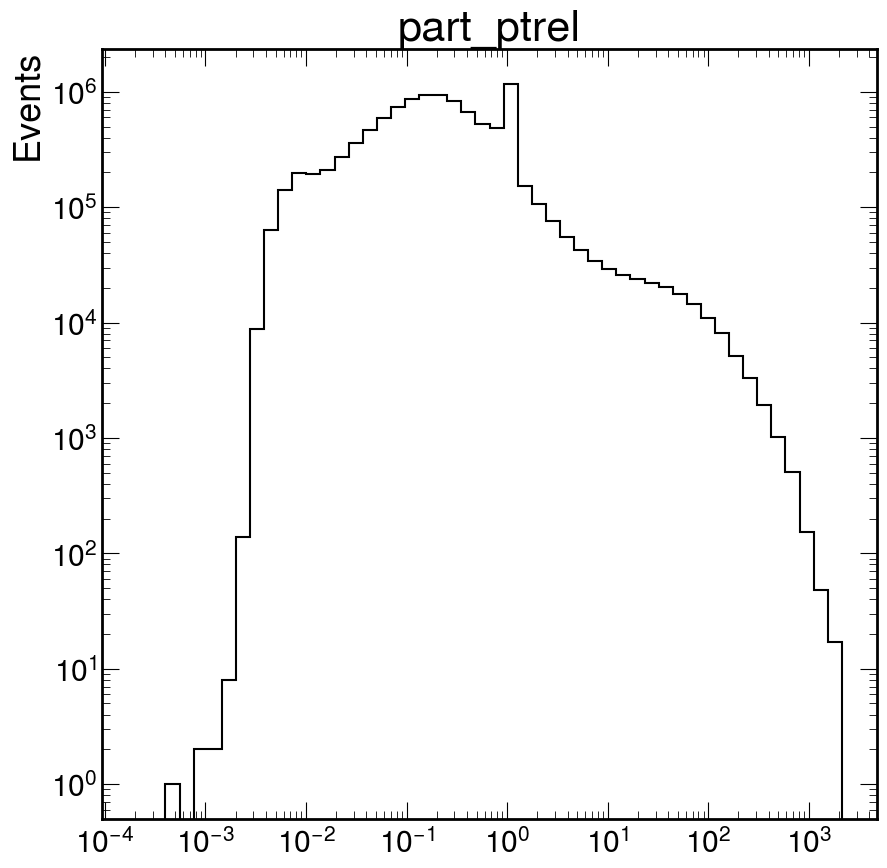

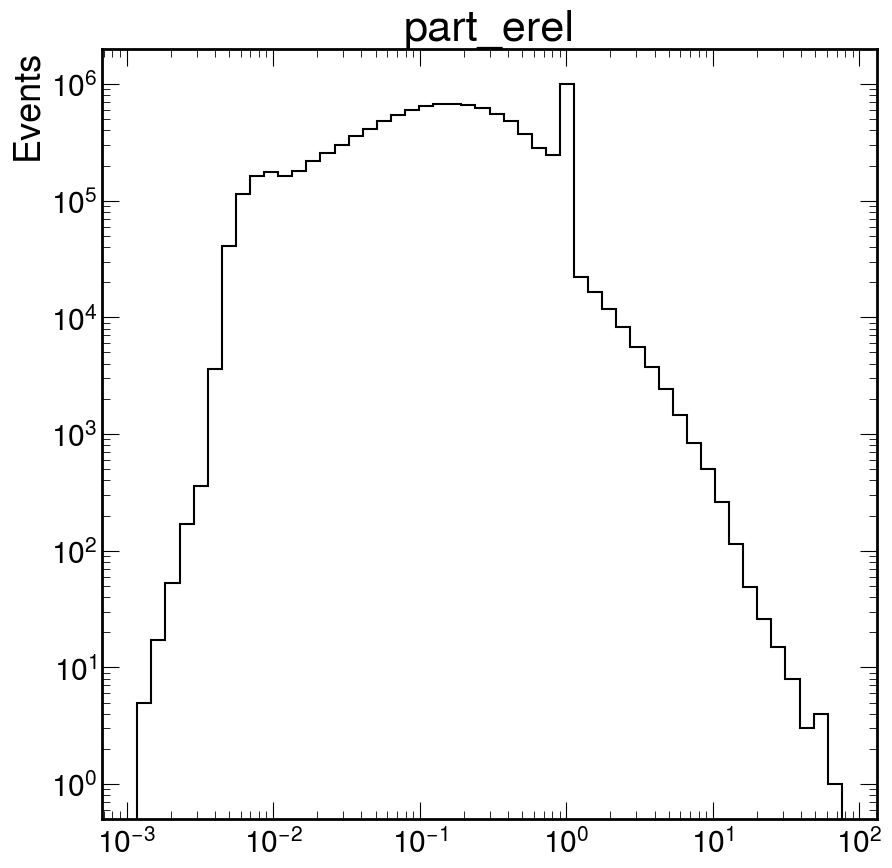

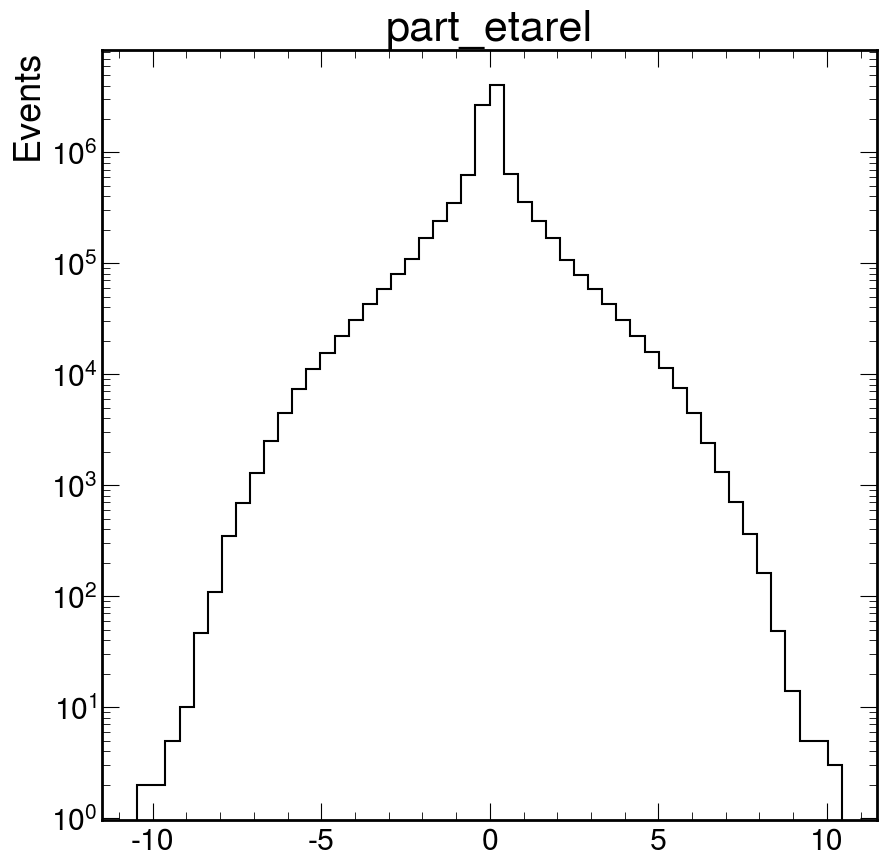

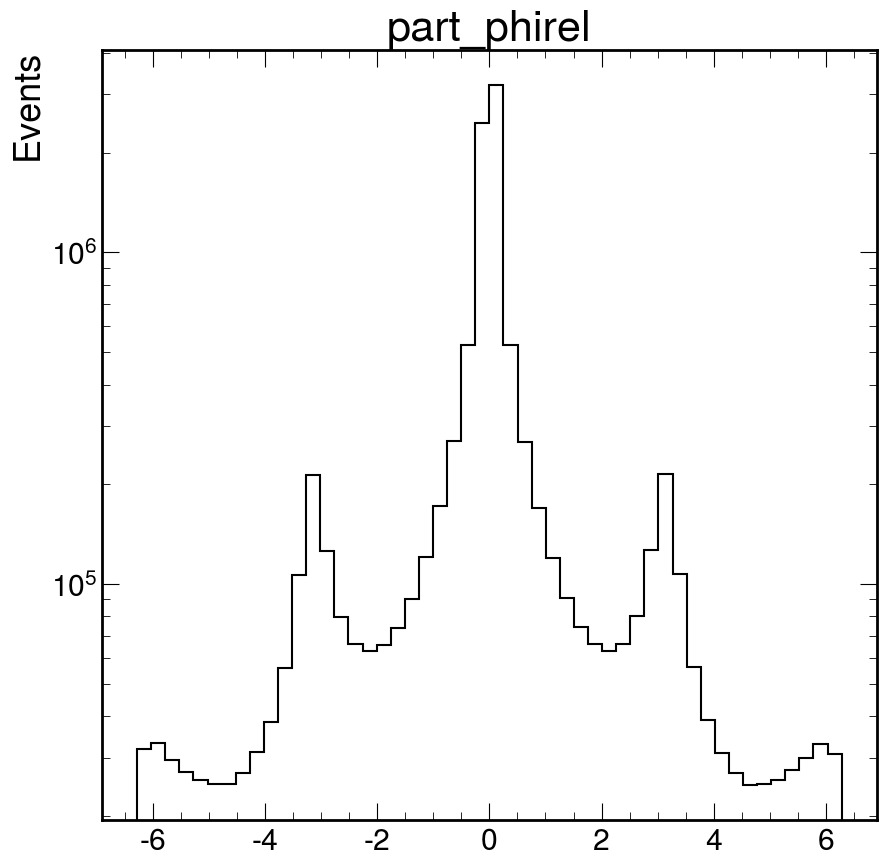

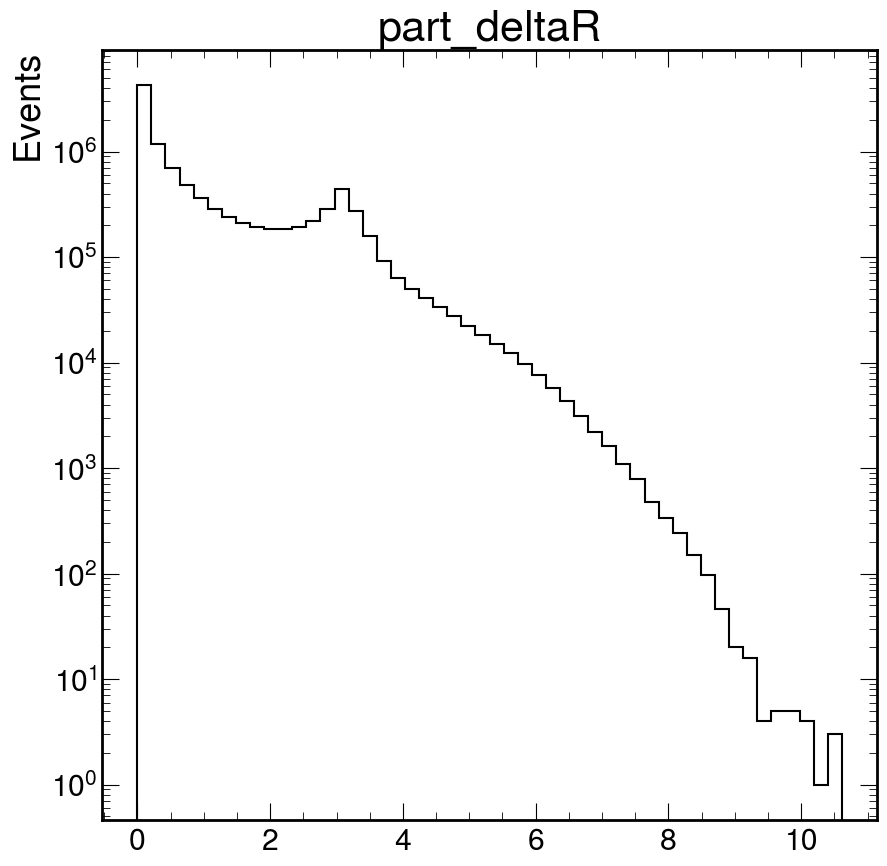

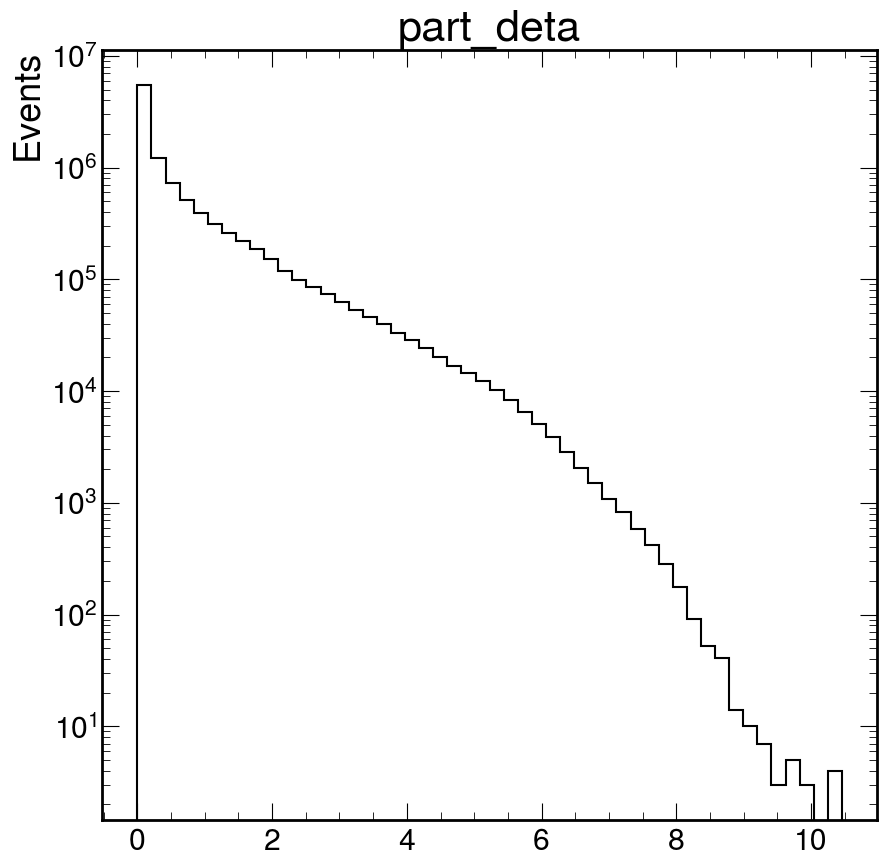

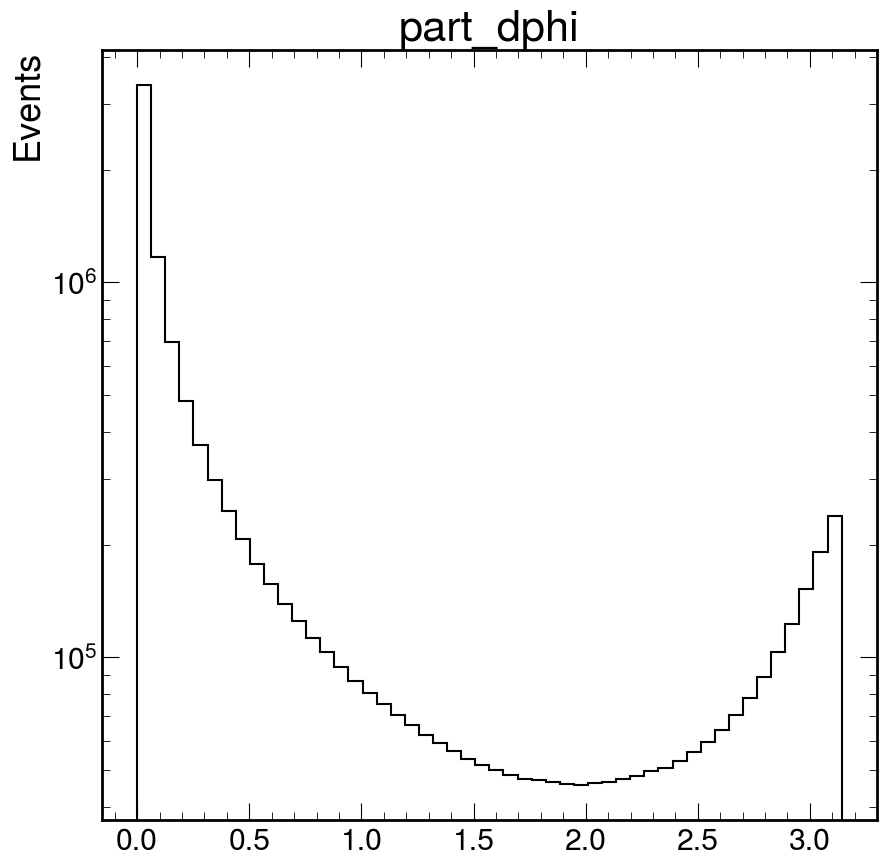

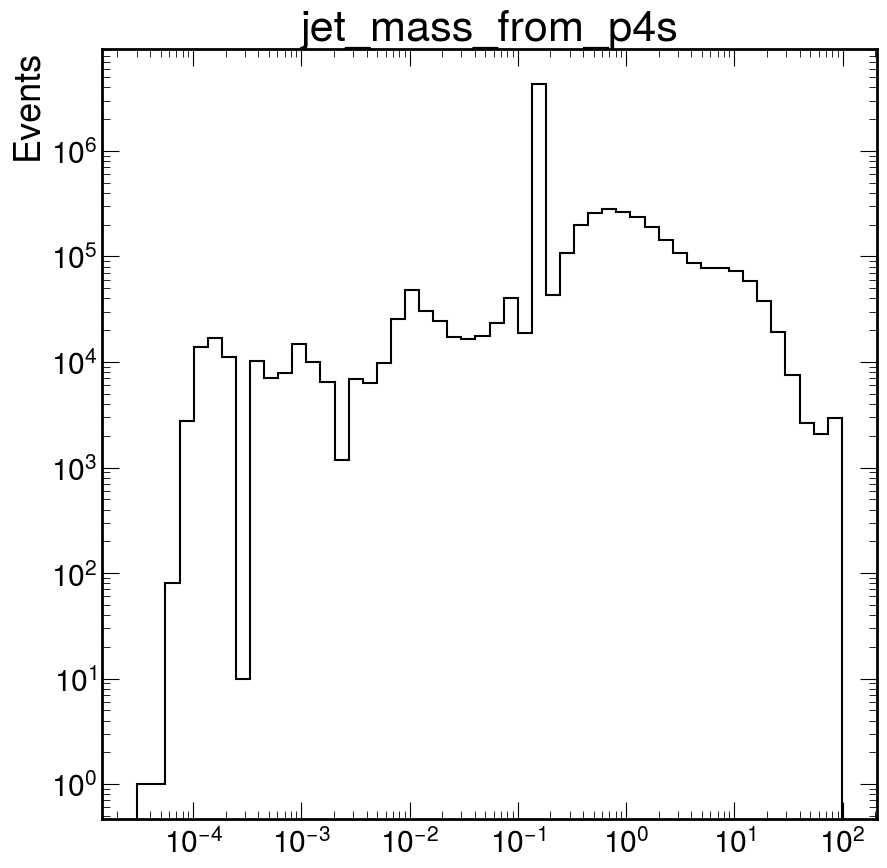

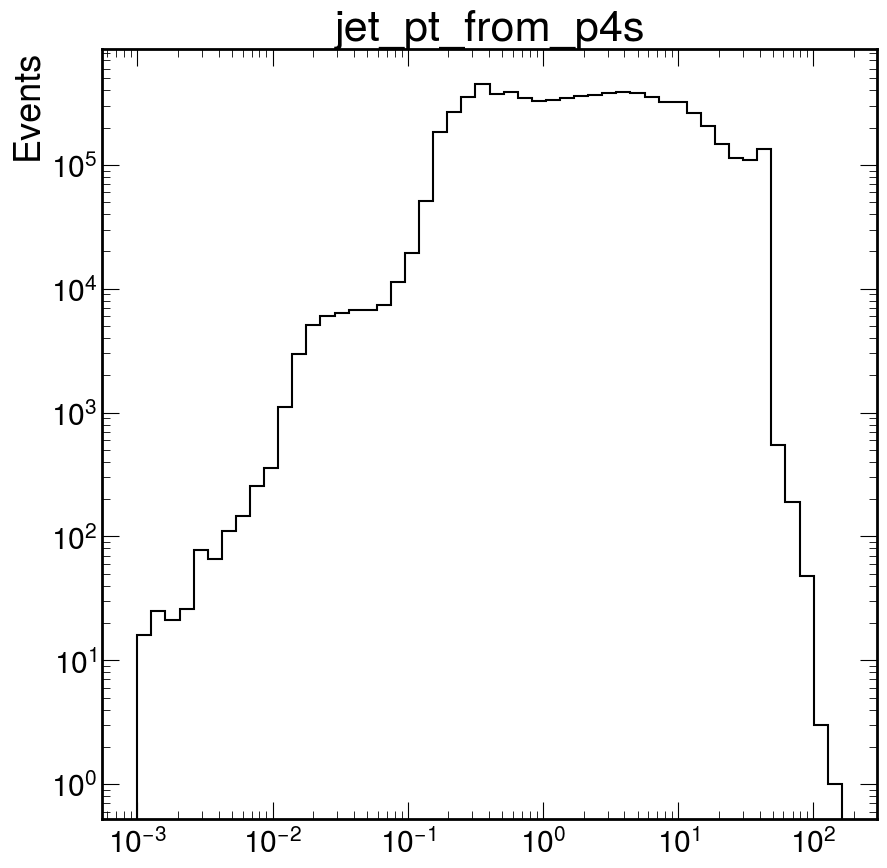

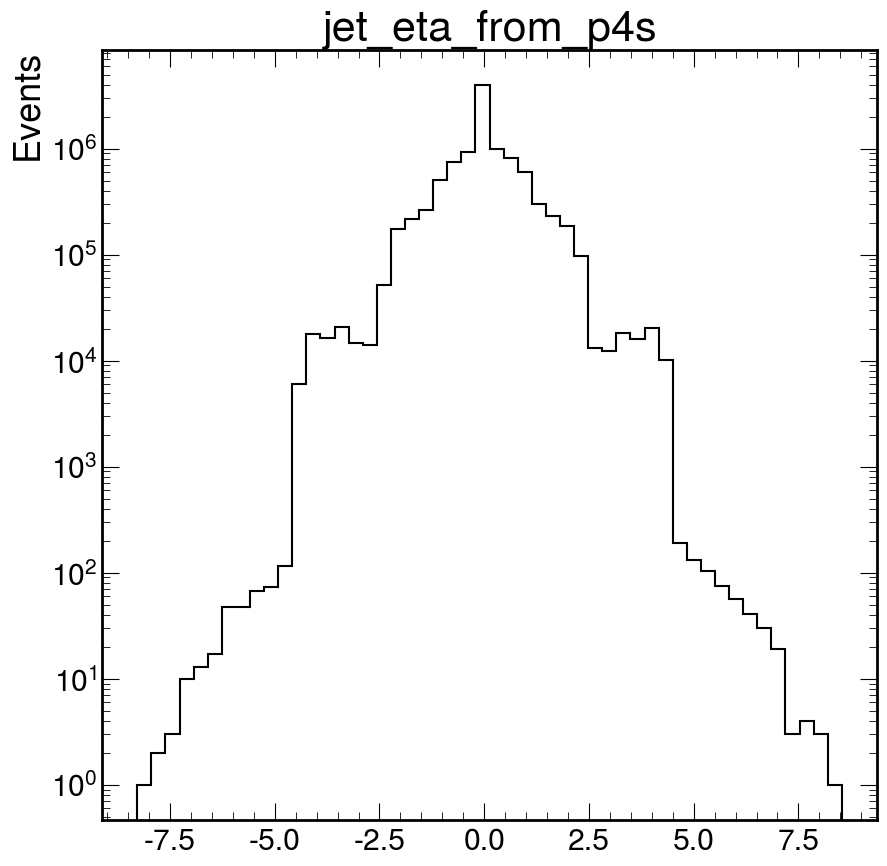

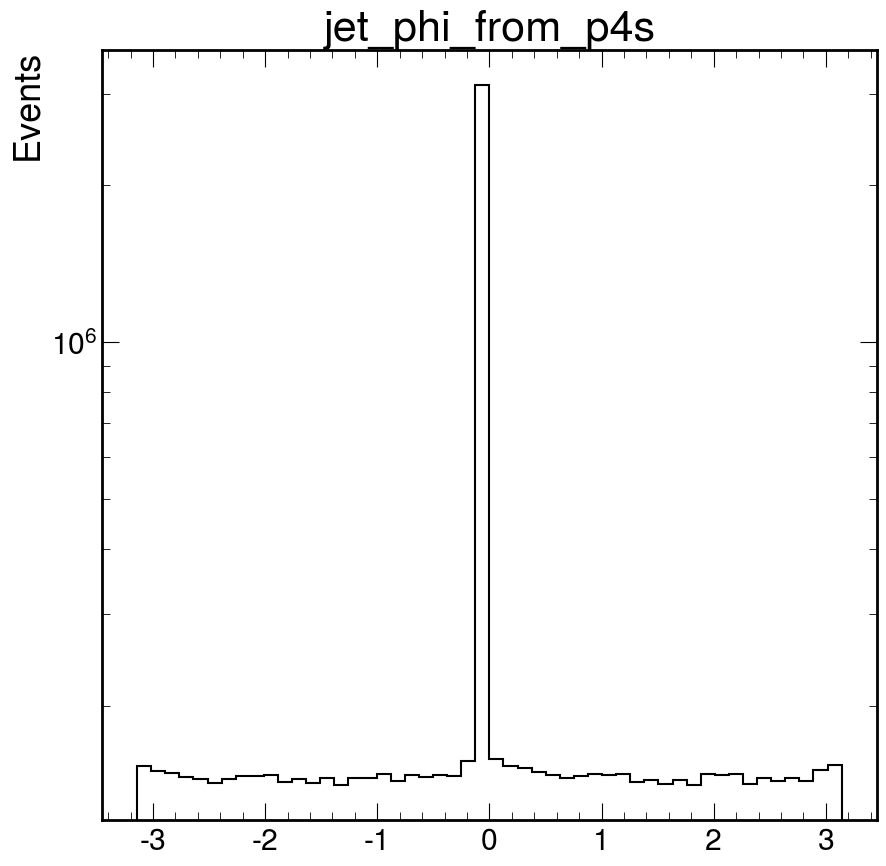

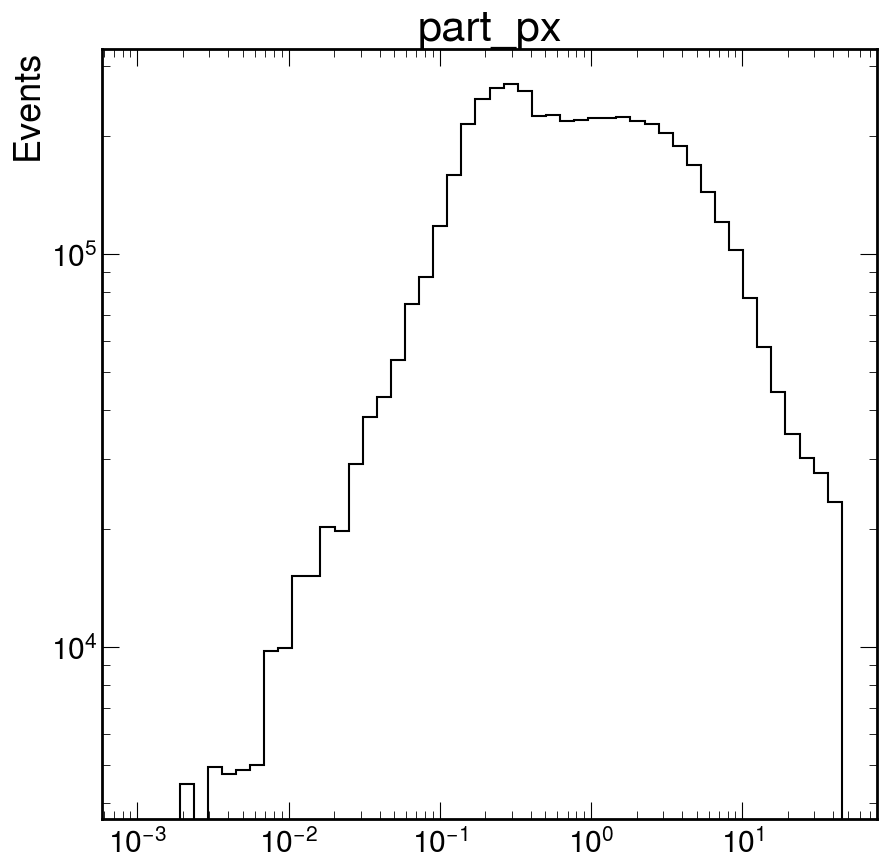

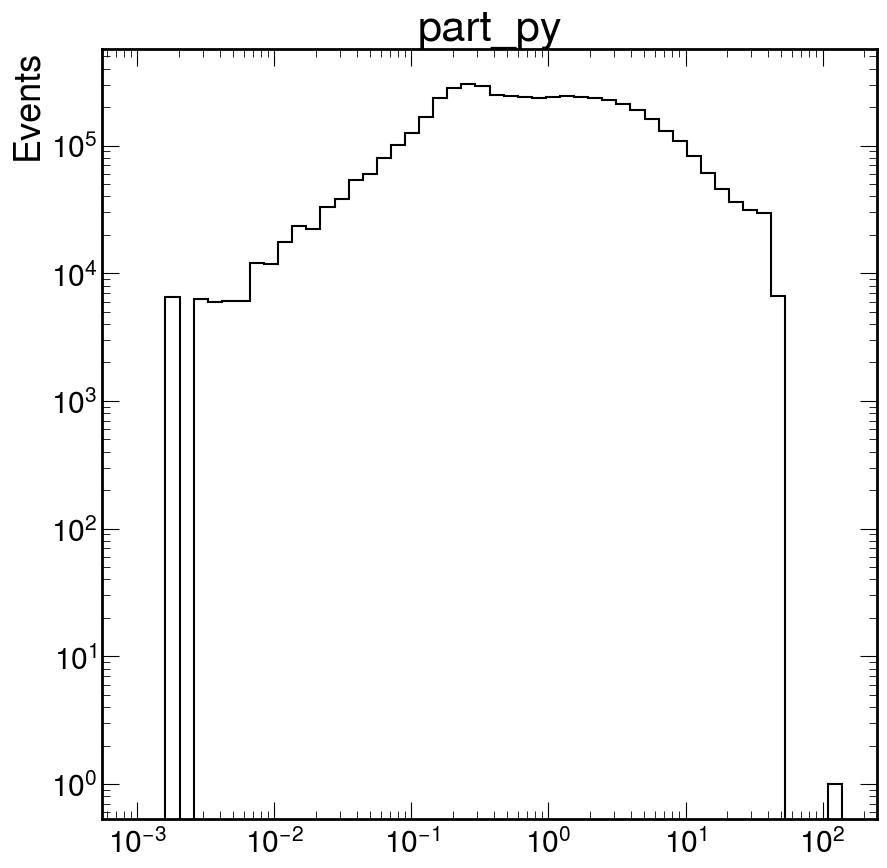

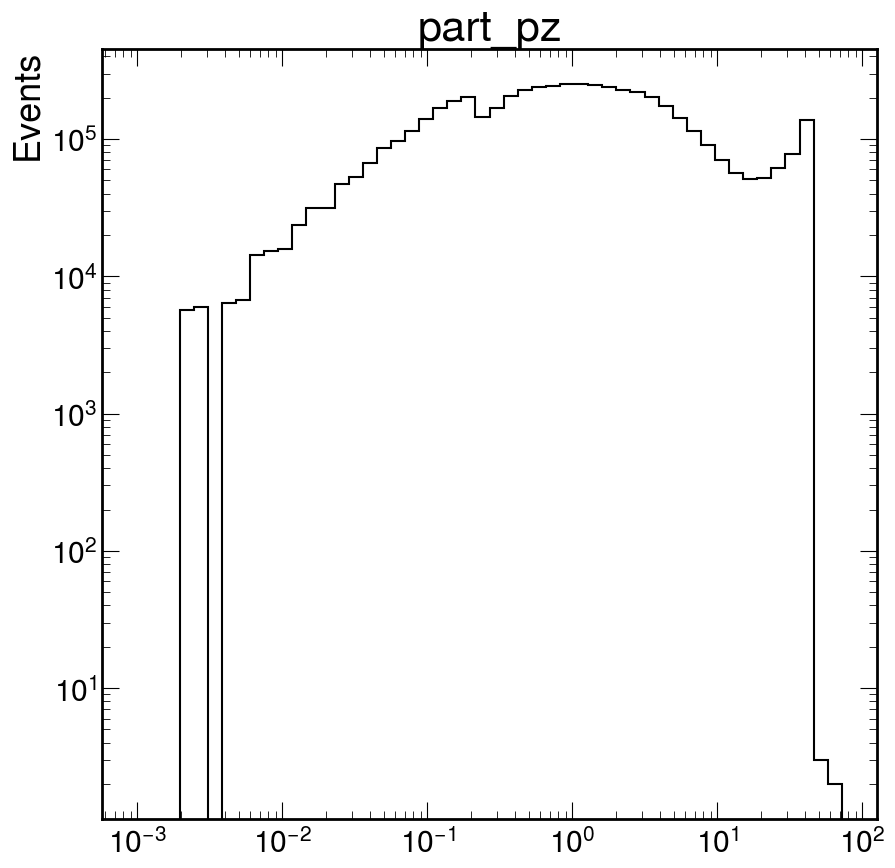

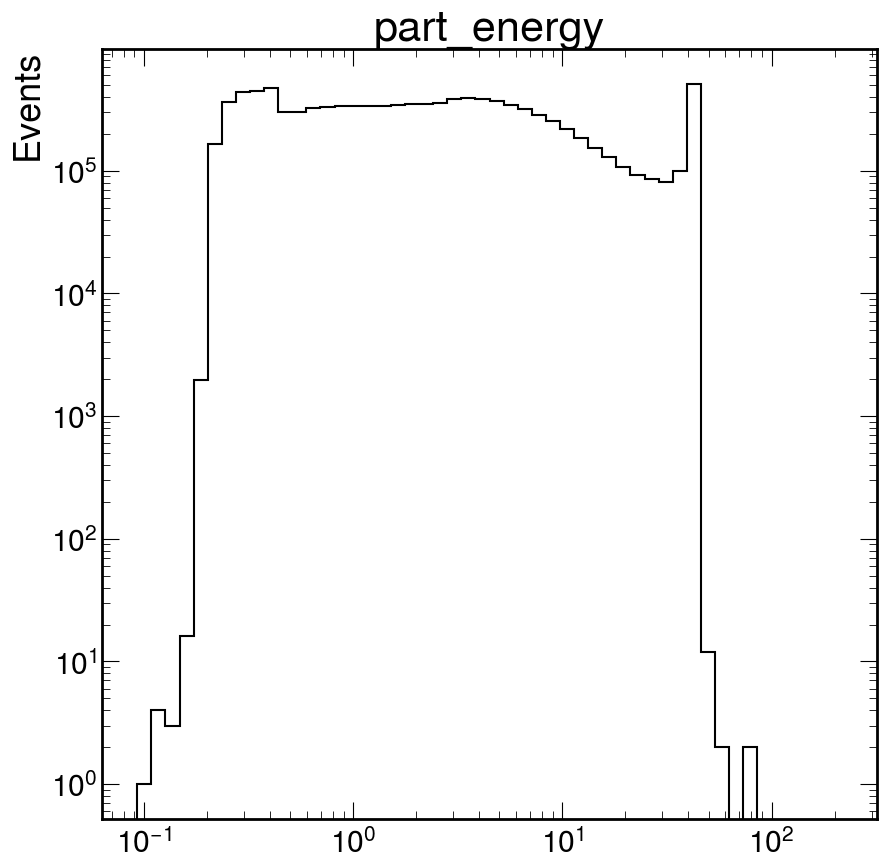

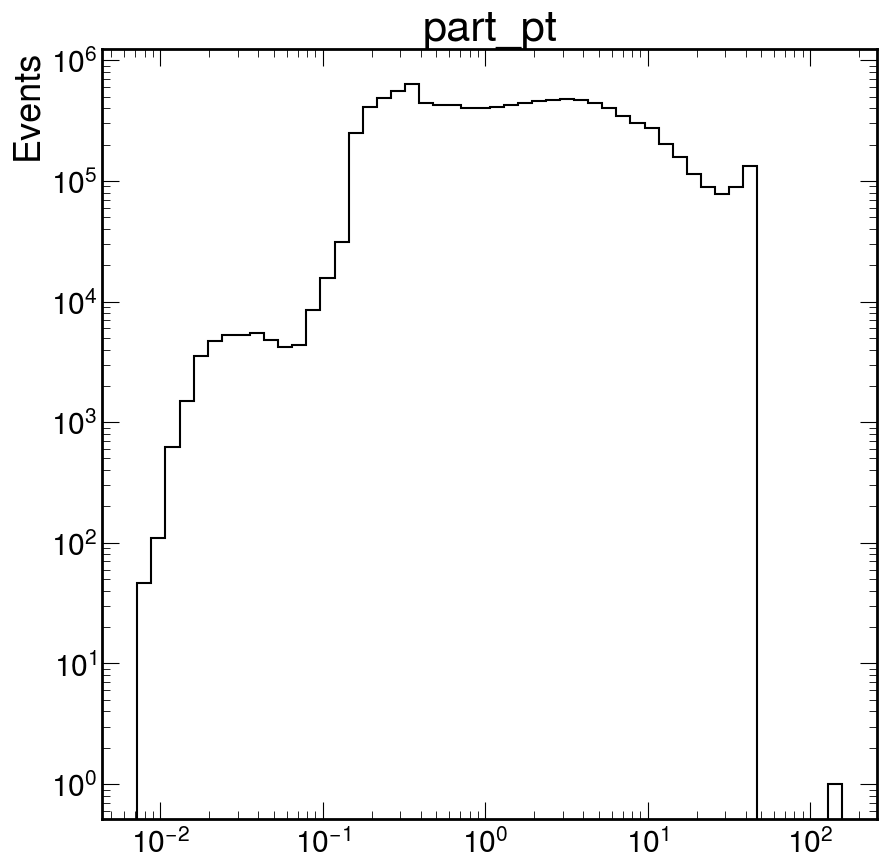

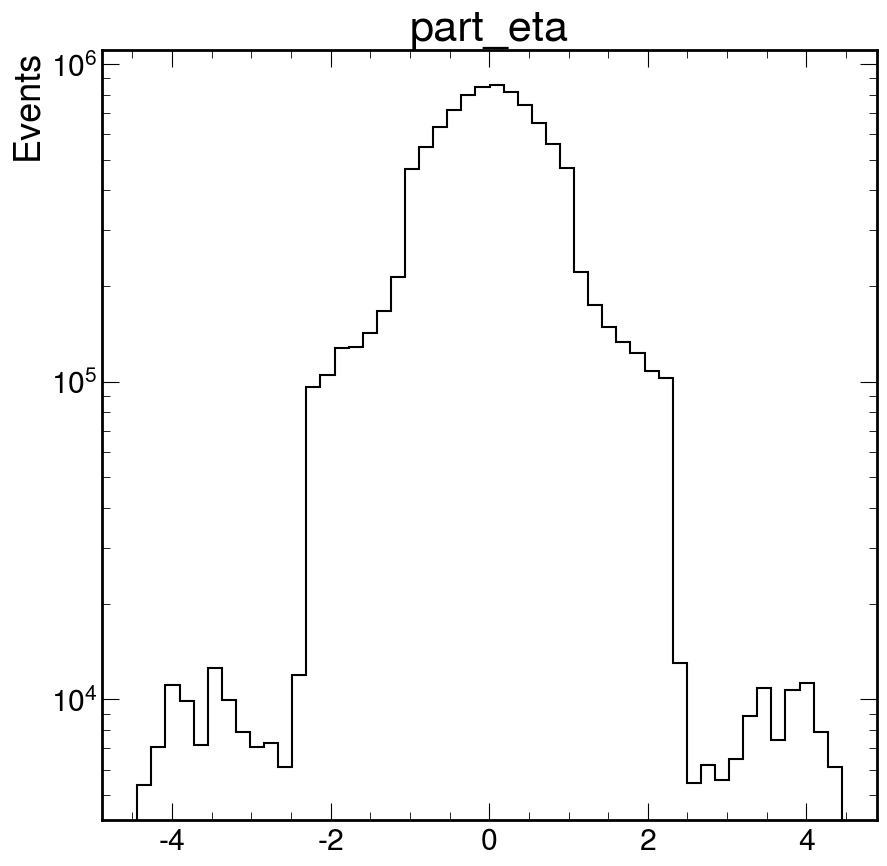

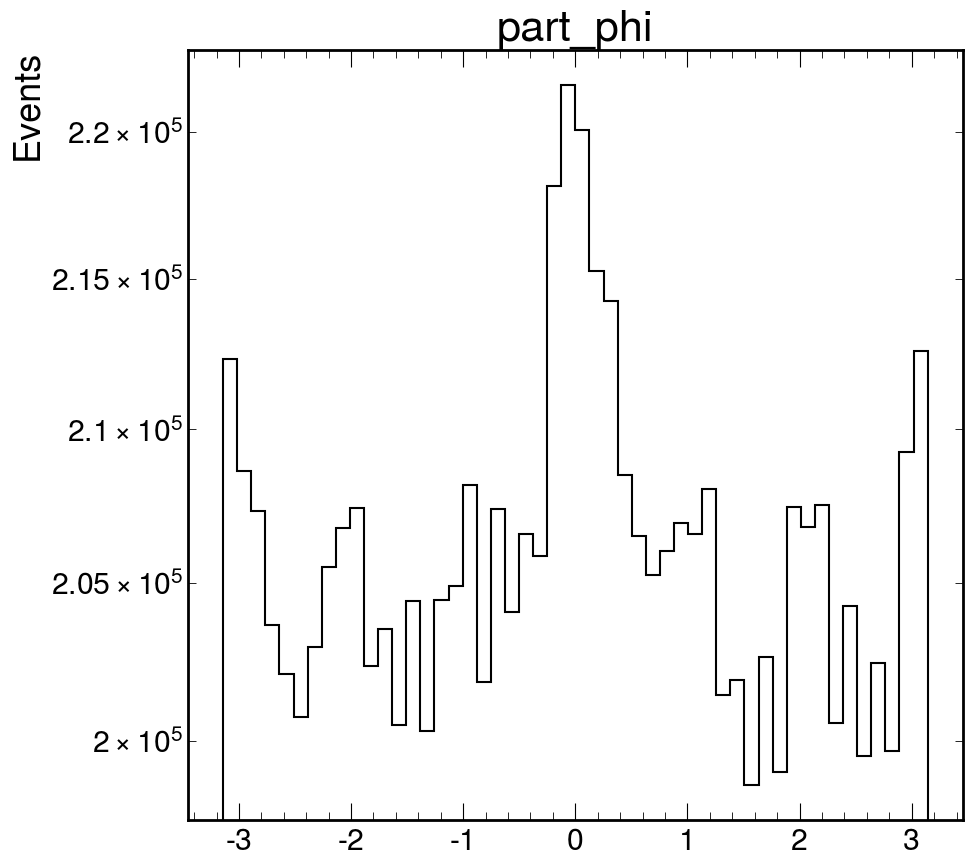

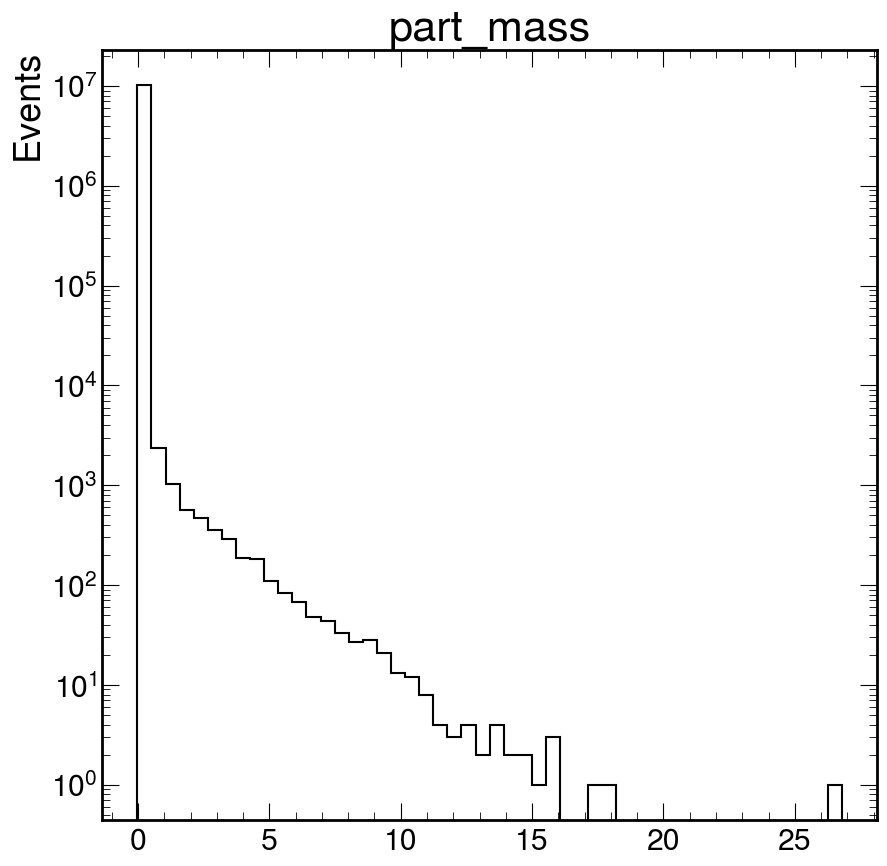

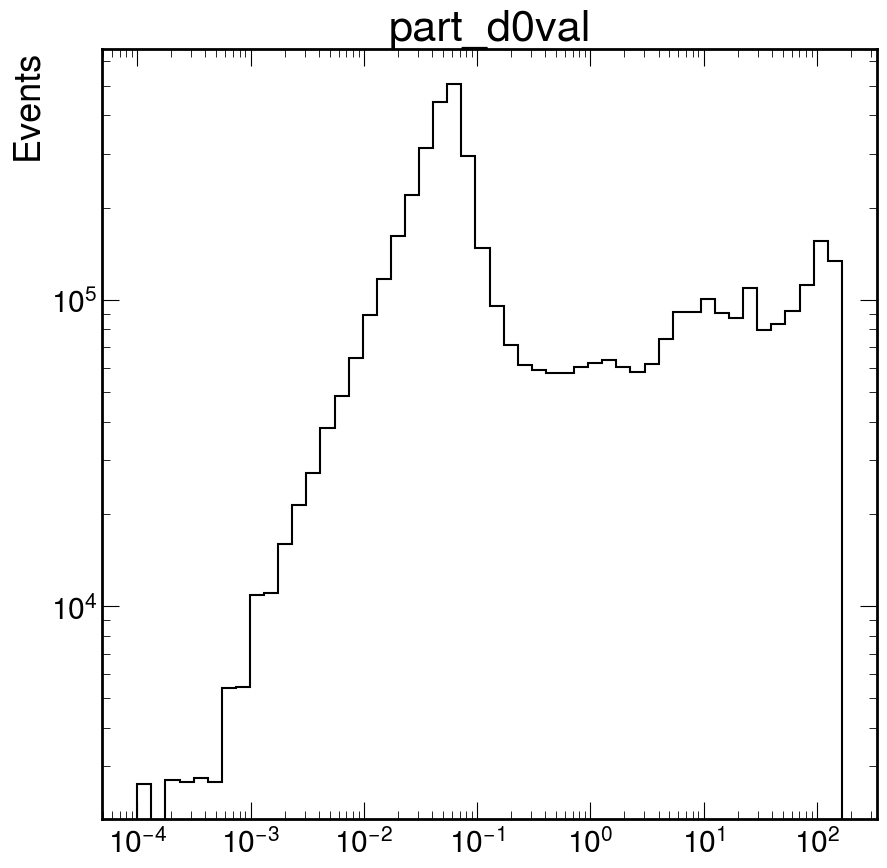

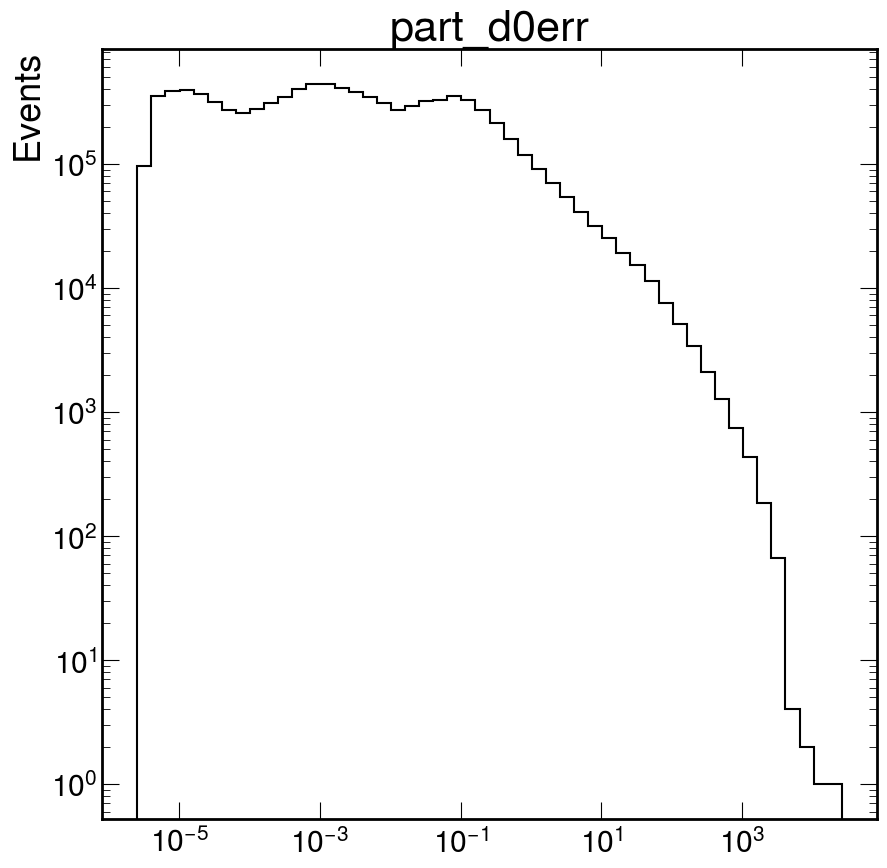

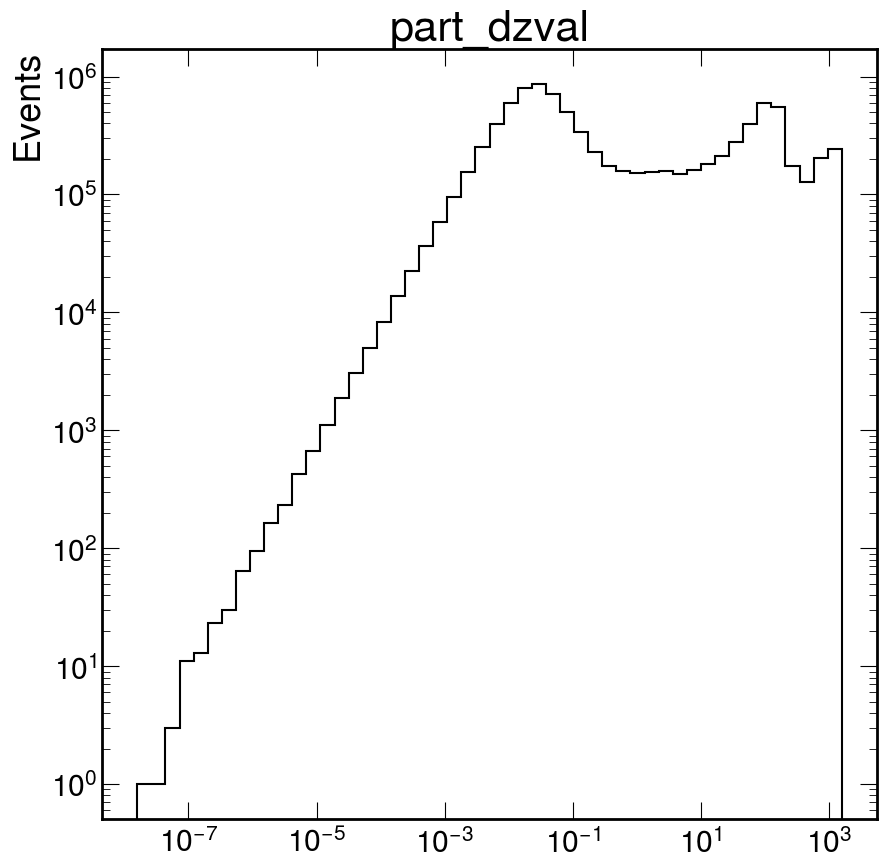

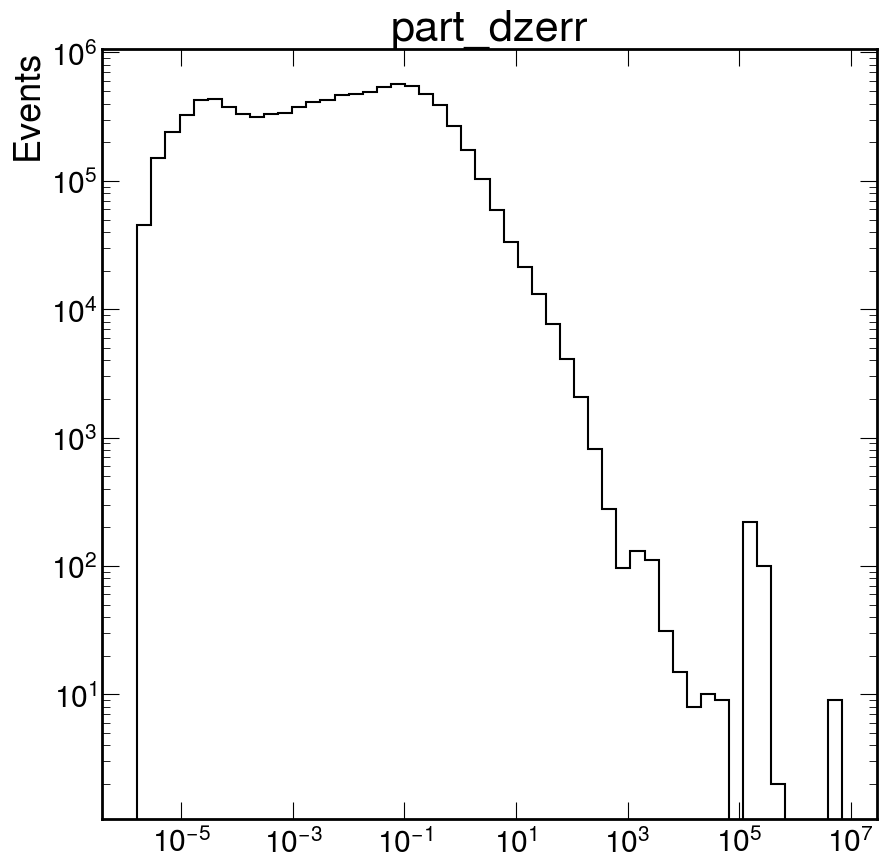

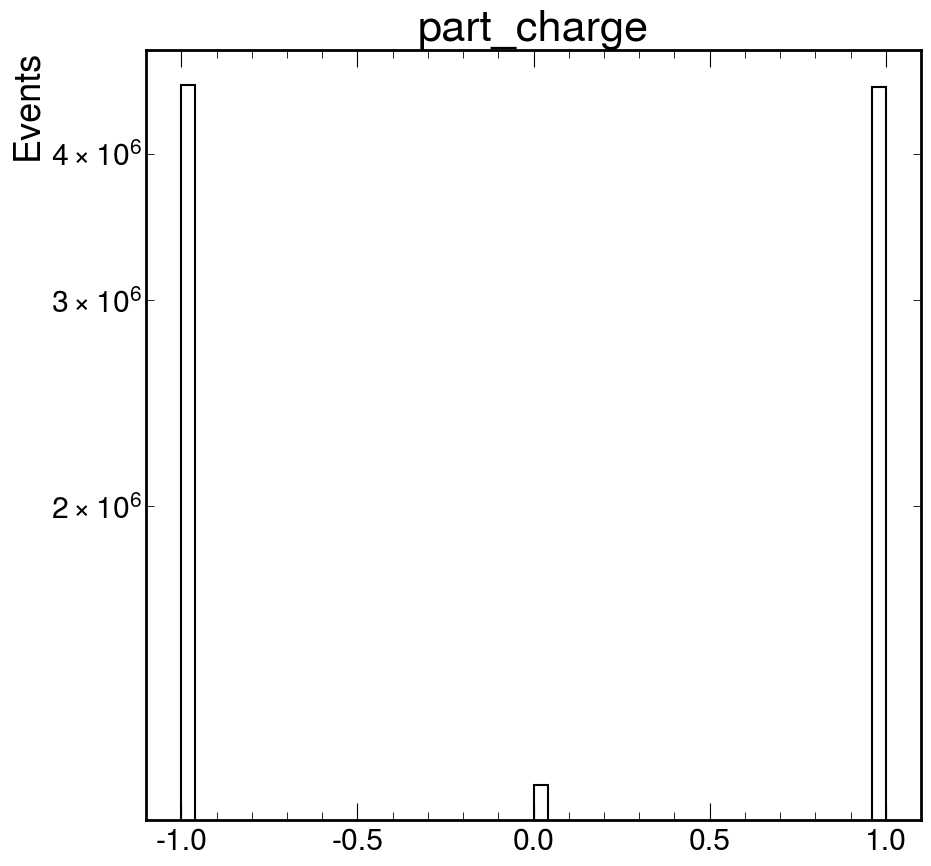

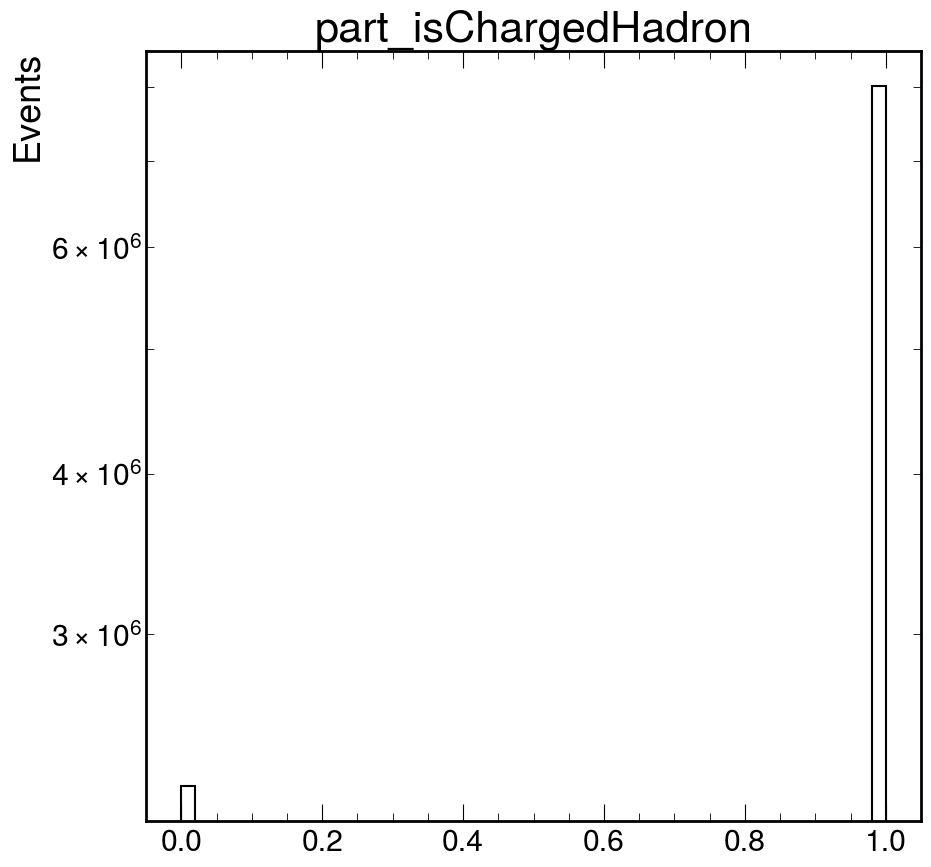

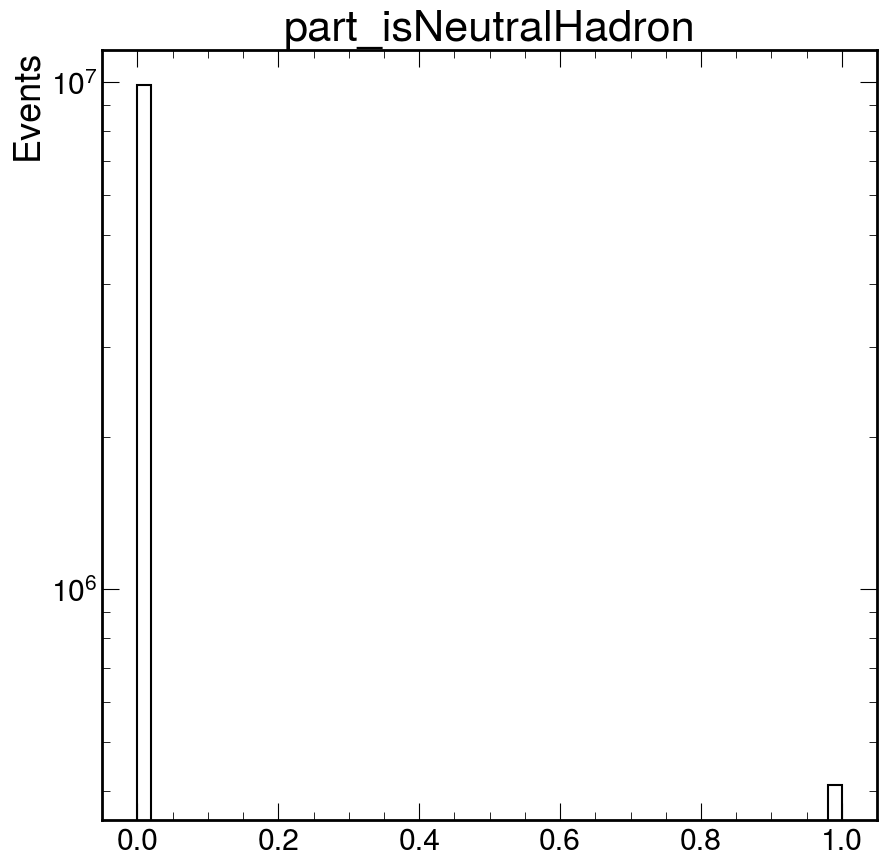

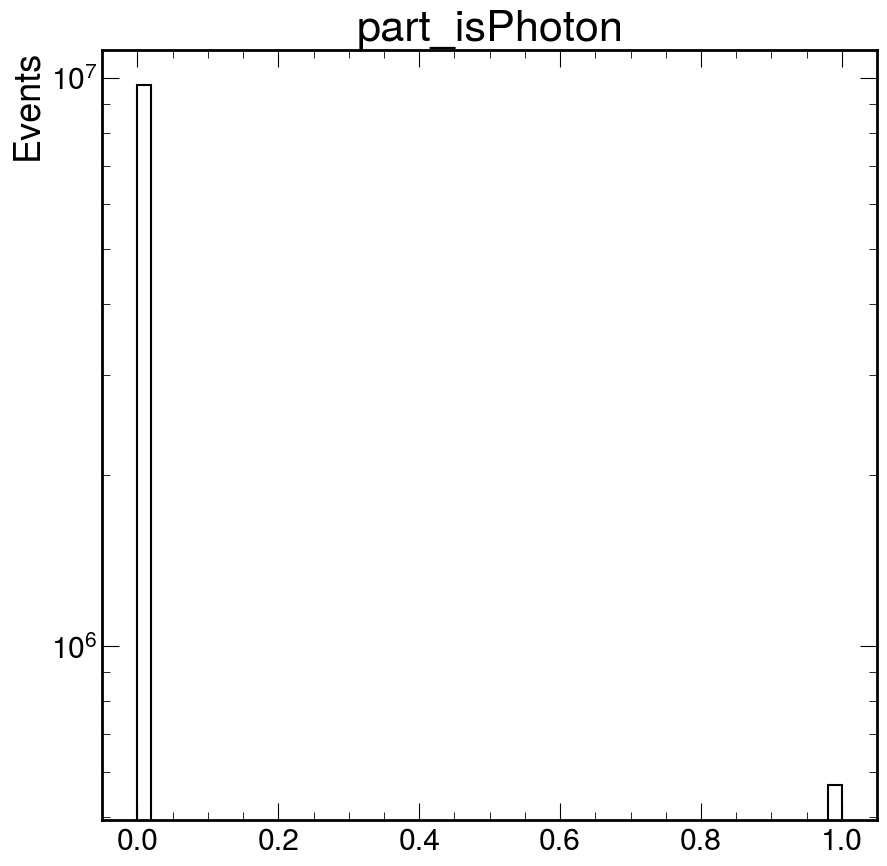

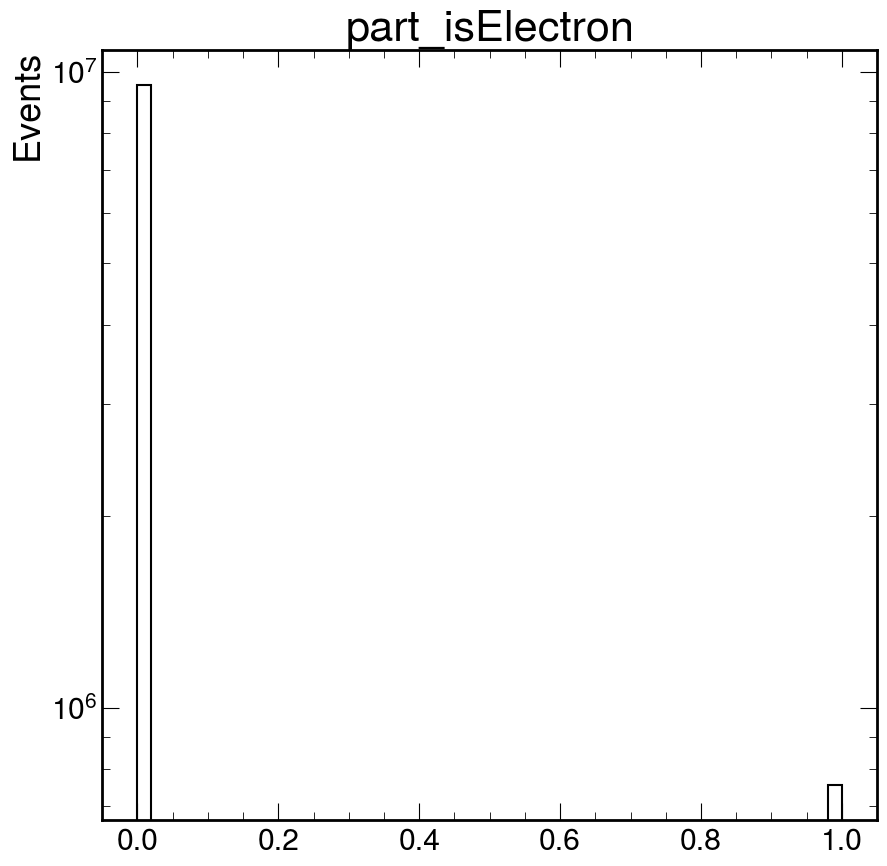

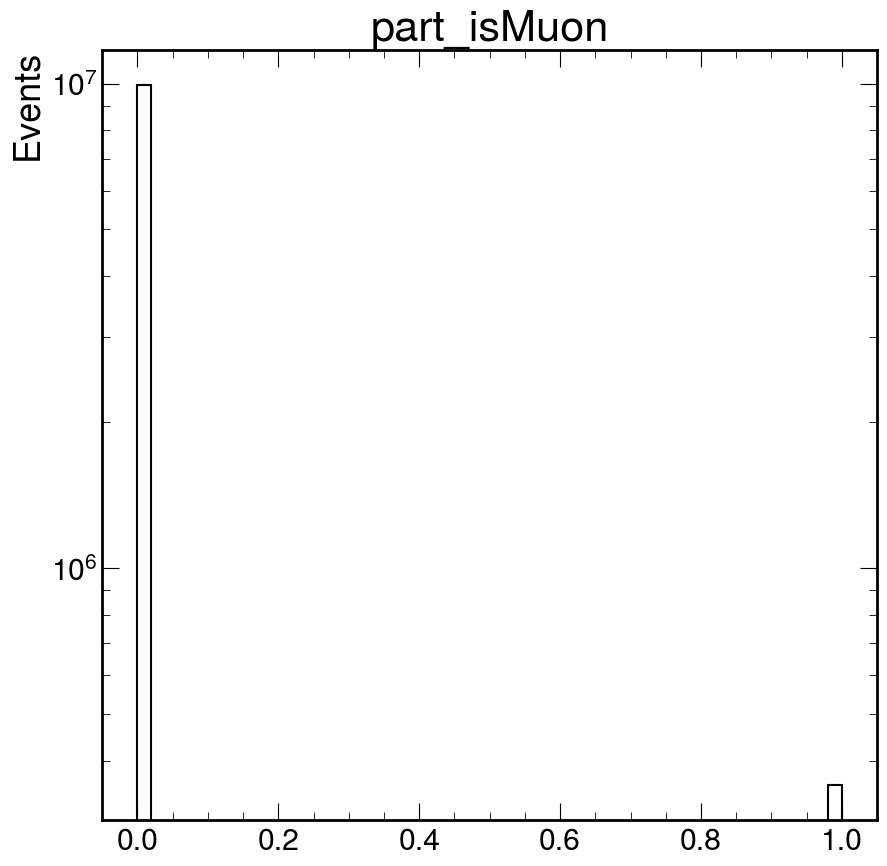

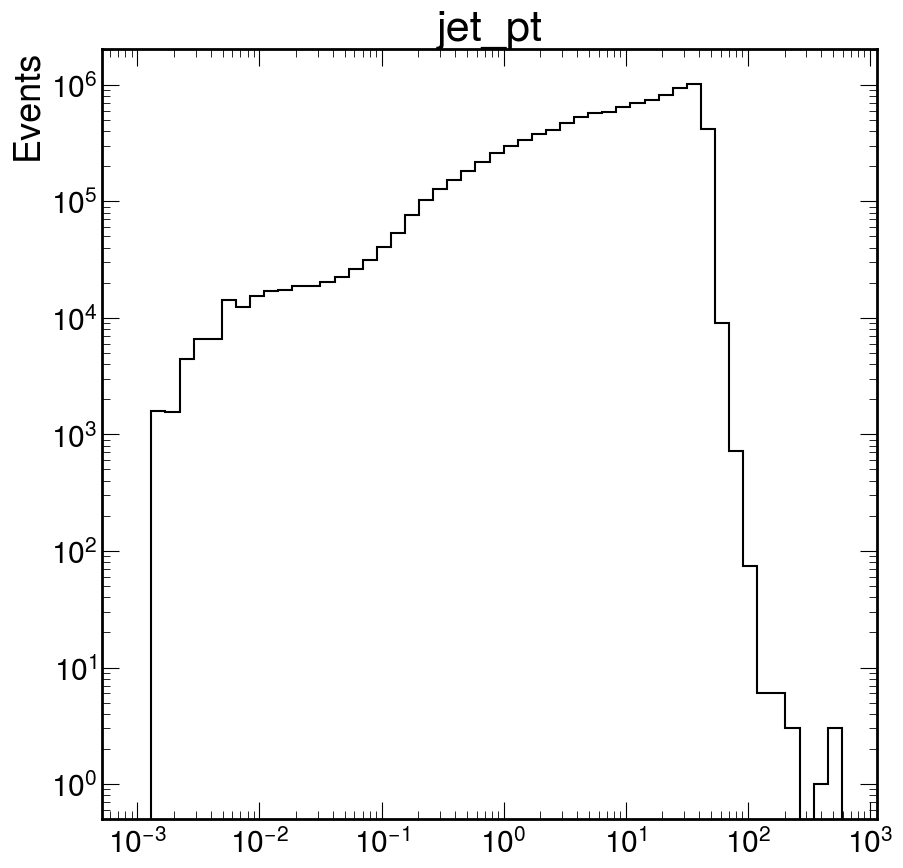

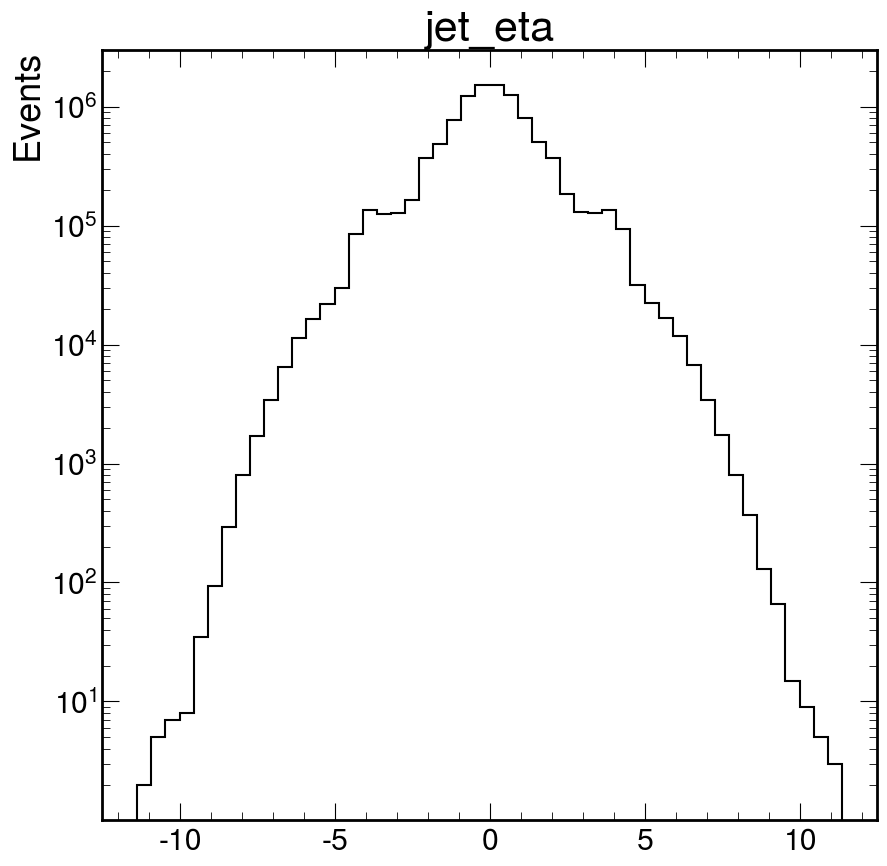

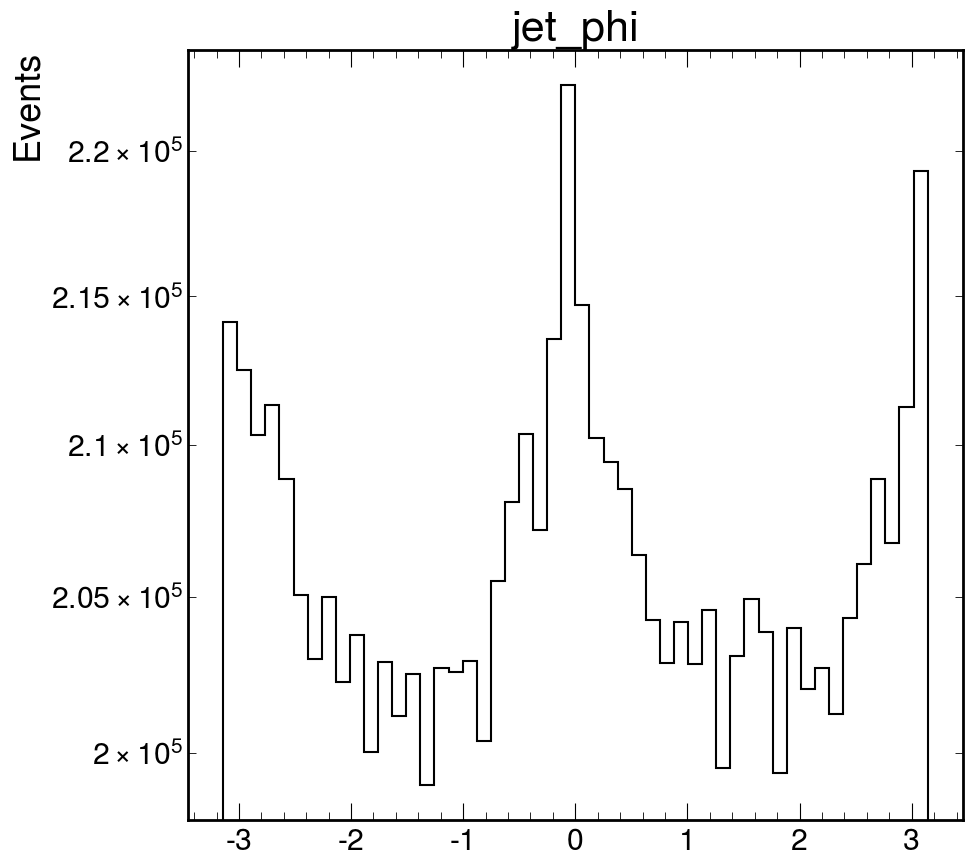

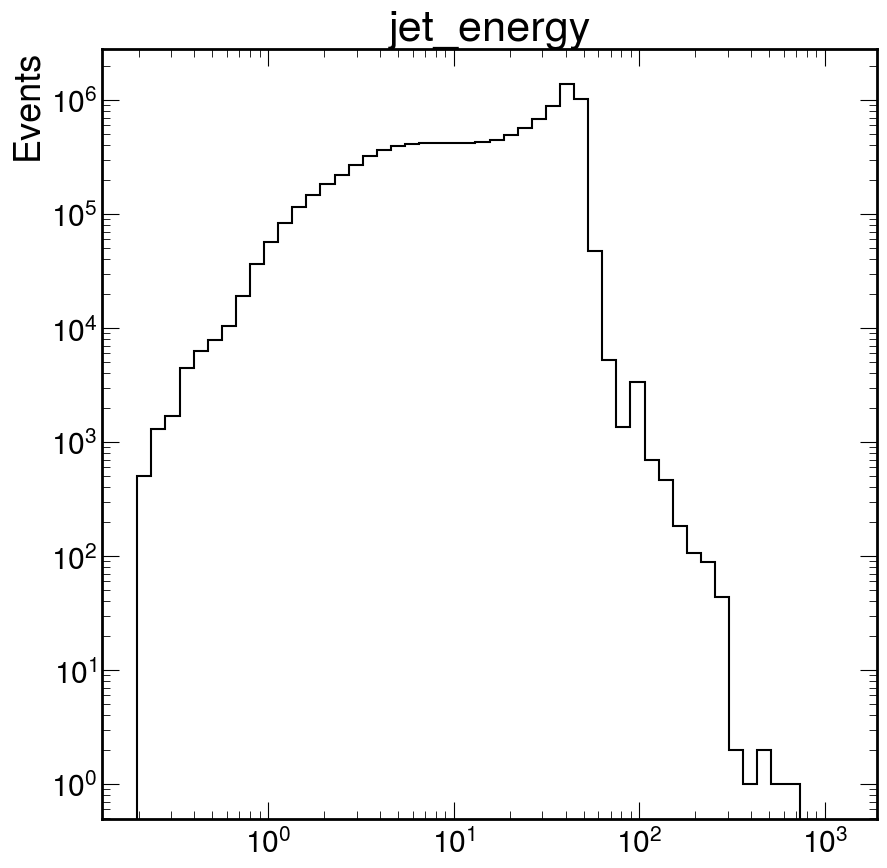

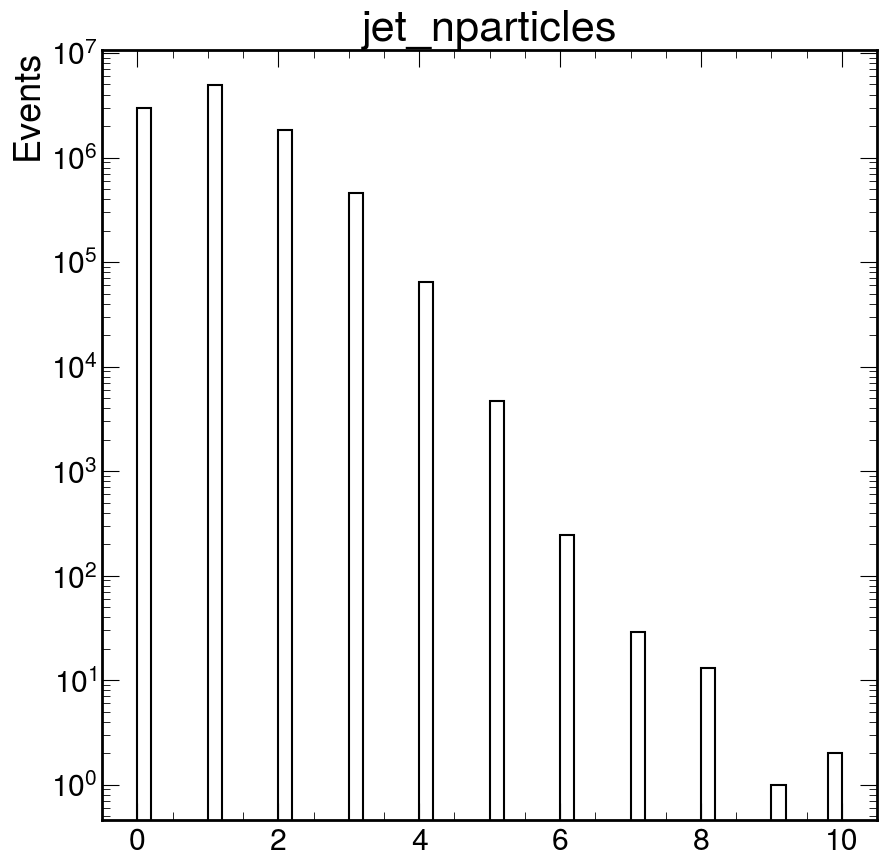

In [92]:
for key, value in info_dict.items():
    data = preprocess_array(all_data[key], jet_level=value["jet_level"], for_log_scale=value["for_log_scale"])
    xscale = "log" if value["for_log_scale"] else "linear"
    fig, ax = plot_distribution(data, title=key, yscale="log", xscale=xscale)
    output_path = os.path.join(OUTPUT_DIR, f"{key}.pdf")
    fig.savefig(output_path, format="pdf")